# LSTM-Based Text Prediction System
## Group Assignment - 5

### Group Members
- Member 1: Nirjara More - 202301100049
- Member 2: Sneha Paliwal
- Member 3: Vaishnavi Phad
- Member 4: Disha Satpute

### Project Details
- Task: Next Word Prediction using LSTM
- Dataset: News Articles (Headlines) using NewsAPI
- Deployment: FastAPI with Swagger UI
- Final Accuracy: (fill after training, e.g., ~20–35% depending on data)


### Dataset Declaration
- Dataset Name: News Headlines Dataset

- Source: https://newsapi.org

- Library Used: requests (to fetch API data)

- Description:
Text data is dynamically collected from multiple news sources using NewsAPI. The dataset consists of news headlines retrieved from various categories such as business, technology, health, and general news. Each headline represents a short textual sequence used for training the LSTM model to predict the next word.



STEP 1: Install All Required Libraries

In [ ]:
!pip install requests tensorflow numpy matplotlib

STEP 2: Fetch Data from NewsAPI

In [ ]:
import requests

print("🔹 Fetching data from NewsAPI...")

API_KEY = "a49e2ff651cb4c298f2a914c8b0711ee"

topics = ["technology", "AI", "business", "science", "health"]

text_data = []

for topic in topics:
    url = f"https://newsapi.org/v2/everything?q={topic}&language=en&pageSize=100&apiKey={API_KEY}"

    response = requests.get(url).json()

    if response.get("status") == "ok":
        for article in response["articles"]:
            if article.get("title"):
                text_data.append(article["title"])
    else:
        print("❌ Error:", response.get("message"))

# Remove duplicates
text_data = list(set(text_data))

print(f"✅ Data fetched successfully")
print(f"📊 Total headlines collected: {len(text_data)}\n")

print("🔍 Sample headlines:")
for i in range(5):
    print(f"{i+1}. {text_data[i]}")

🔹 Fetching data from NewsAPI...
✅ Data fetched successfully
📊 Total headlines collected: 388

🔍 Sample headlines:
1. Soviet CDs And CD Players Existed, And They Were Strange
2. A jury is about to decide the fate of Ticketmaster
3. Poem: ‘How I Became a Spitfire Pilot during My Cataract Operation’
4. Spirit is broken
5. AI failure could trigger the next financial crisis, warns Elizabeth Warren


In [ ]:
import requests

API_KEY = "a49e2ff651cb4c298f2a914c8b0711ee"

topics = ["technology", "AI", "business", "science", "health"]

text_data = []

for topic in topics:
    url = f"https://newsapi.org/v2/everything?q={topic}&language=en&pageSize=100&apiKey={API_KEY}"

    response = requests.get(url).json()

    if response.get("status") == "ok":
        for article in response["articles"]:
            if article.get("title"):
                text_data.append(article["title"])
    else:
        print("Error:", response.get("message"))

# remove duplicates
text_data = list(set(text_data))

print("Total headlines:", len(text_data))

Total headlines: 388


STEP 3: Data Preprocessing

3.1 Clean the text

In [ ]:
import re

print("\n🔹 Cleaning text data...")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

text_data = [clean_text(text) for text in text_data if text]

print("✅ Text cleaned successfully")

print("\n🔍 Sample cleaned text:")
for i in range(5):
    print(f"{i+1}. {text_data[i]}")


🔹 Cleaning text data...
✅ Text cleaned successfully

🔍 Sample cleaned text:
1. soviet cds and cd players existed and they were strange
2. a jury is about to decide the fate of ticketmaster
3. poem how i became a spitfire pilot during my cataract operation
4. spirit is broken
5. ai failure could trigger the next financial crisis warns elizabeth warren


3.2 Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

print("\n🔹 Tokenizing text...")

tokenizer = Tokenizer()
tokenizer.fit_on_texts(text_data)

total_words = len(tokenizer.word_index) + 1

print(f"✅ Tokenization complete")
print(f"📊 Total unique words: {total_words}")


🔹 Tokenizing text...
✅ Tokenization complete
📊 Total unique words: 1967


3.3 Create Sequences

In [27]:
input_sequences = []

for line in text_data:
    token_list = tokenizer.texts_to_sequences([line])[0]

    if token_list and len(token_list) > 1:  # IMPORTANT FIX
        for i in range(1, len(token_list)):
            seq = token_list[:i+1]
            if len(seq) > 1:
                input_sequences.append(seq)

In [28]:
print("\n🔹 Cleaning invalid sequences...")

clean_sequences = []

for seq in input_sequences:
    if len(seq) > 1:   # must have at least 2 elements
        clean_sequences.append(seq)

input_sequences = clean_sequences

print(f"✅ Valid sequences remaining: {len(input_sequences)}")


🔹 Cleaning invalid sequences...
✅ Valid sequences remaining: 4004


3.4 Padding

In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

print("\n🔹 Applying padding...")

max_seq_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')

print(f"✅ Padding applied")
print(f"📊 Max sequence length: {max_seq_len}")


🔹 Applying padding...
✅ Padding applied
📊 Max sequence length: 24


In [33]:
print("\n🔹 Removing zero rows from dataset...")

# Remove rows where all values are 0
non_zero_indices = np.where(X.sum(axis=1) != 0)

X = X[non_zero_indices]
y = y[non_zero_indices]

print("✅ Zero rows removed")
print("X shape:", X.shape)
print("y shape:", y.shape)


🔹 Removing zero rows from dataset...
✅ Zero rows removed
X shape: (4004, 23)
y shape: (4004,)


In [34]:
print("\n🔹 Converting data types...")

X = X.astype('int32')
y = y.astype('int32')

print("✅ Data types fixed")


🔹 Converting data types...
✅ Data types fixed


3.5 Split Data

In [30]:
print("\n🔹 Splitting data into X and y...")

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("✅ Data split complete")
print(f"📊 X shape: {X.shape}")
print(f"📊 y shape: {y.shape}")


🔹 Splitting data into X and y...
✅ Data split complete
📊 X shape: (4004, 23)
📊 y shape: (4004,)


3.6 One-Hot Encoding

In [ ]:
from tensorflow.keras.utils import to_categorical

print("\n🔹 Applying one-hot encoding...")

y = to_categorical(y, num_classes=total_words)

print("✅ One-hot encoding complete")
print(f"📊 y shape after encoding: {y.shape}")


🔹 Applying one-hot encoding...
✅ One-hot encoding complete
📊 y shape after encoding: (4004, 1967)


In [31]:
print("\n🔹 Final data check...")

print("Any empty rows in X:", (X.sum(axis=1) == 0).any())
print("X shape:", X.shape)
print("y shape:", y.shape)


🔹 Final data check...
Any empty rows in X: False
X shape: (4004, 23)
y shape: (4004,)


STEP 4: Build LSTM Model

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

print("\n🔹 Building LSTM model...")

model = Sequential()

print("➡️ Adding Embedding layer...")
model.add(Embedding(total_words, 100, input_length=max_seq_len-1))

print("➡️ Adding LSTM layer...")
model.add(LSTM(128))

print("➡️ Adding Dense output layer...")
model.add(Dense(total_words, activation='softmax'))

print("➡️ Compiling model...")
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\n✅ Model built and compiled successfully!\n")

print("📊 Model Summary:\n")
model.summary()


🔹 Building LSTM model...
➡️ Adding Embedding layer...
➡️ Adding LSTM layer...
➡️ Adding Dense output layer...
➡️ Compiling model...

✅ Model built and compiled successfully!

📊 Model Summary:



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

4.1 Train the model

In [37]:
print("\n🔹 Training model...")

history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    verbose=1
)

print("✅ Training complete")


🔹 Training model...
Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.0222 - loss: 7.2799
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - accuracy: 0.0245 - loss: 6.7916
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.0285 - loss: 6.6256
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.0322 - loss: 6.4655
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.0372 - loss: 6.3137
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.0467 - loss: 6.1511
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.0470 - loss: 5.9746
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.0490 - loss: 5.8024
Epoch 9/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.0574 - loss: 5.6253
Epoch 10/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - accuracy: 0.0587 - loss: 5.4594
Epoch 11/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.0637 - loss: 5.2958
Epoch 12/20
126/126

STEP 5: Save the Model & Test Predictions

5.1 Save the model

In [38]:
import pickle

print("\n🔹 Saving model and tokenizer...")

# Save trained model
model.save("lstm_text_model.h5")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Model saved as lstm_text_model.h5")
print("✅ Tokenizer saved as tokenizer.pkl\n")


🔹 Saving model and tokenizer...
✅ Model saved as lstm_text_model.h5
✅ Tokenizer saved as tokenizer.pkl



In [39]:
print("🔹 Creating prediction function...")

def predict_next_words(seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_seq_len-1,
            padding='pre'
        )

        predicted = model.predict(token_list, verbose=0)
        predicted_word = tokenizer.index_word.get(predicted.argmax(), "")

        seed_text += " " + predicted_word

    return seed_text

print("✅ Prediction function ready\n")

🔹 Creating prediction function...
✅ Prediction function ready



5.2 Test Predictions

In [40]:
print("🔹 Testing model predictions...\n")

test_sentences = [
    "breaking news",
    "latest technology",
    "artificial intelligence",
    "stock market"
]

for sentence in test_sentences:
    result = predict_next_words(sentence, 5)
    print(f"🧠 Input: {sentence}")
    print(f"✨ Predicted: {result}\n")

🔹 Testing model predictions...

🧠 Input: breaking news
✨ Predicted: breaking news the competitor musk in the

🧠 Input: latest technology
✨ Predicted: latest technology a new business is the

🧠 Input: artificial intelligence
✨ Predicted: artificial intelligence is the new over ai

🧠 Input: stock market
✨ Predicted: stock market is the new is is



STEP 6: Building the FastAPI /predict Endpoint

6.1 — Write the FastAPI App

In [41]:
# Write the FastAPI app to a file

api_code = '''
import pickle
import numpy as np
from fastapi import FastAPI
from pydantic import BaseModel
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Initialize app
app = FastAPI(
    title="LSTM News Prediction API",
    description="Predicts next words from news headlines using LSTM",
    version="1.0.0"
)

# Load model and tokenizer
model = load_model("lstm_text_model.h5")
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

# IMPORTANT: use same value as training
SEQ_LENGTH = 23   # replace with your max_seq_len-1
VOCAB_SIZE = len(tokenizer.word_index) + 1

# Request body
class PredictRequest(BaseModel):
    seed_text: str
    num_words: int = 5

# Response body
class PredictResponse(BaseModel):
    input_text: str
    predicted_text: str
    next_words: list

# Root endpoint
@app.get("/")
def home():
    return {
        "message": "News LSTM Prediction API is running!",
        "endpoints": {
            "predict": "/predict",
            "docs": "/docs",
            "health": "/health"
        }
    }

# Health check
@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "LSTM",
        "vocab_size": VOCAB_SIZE
    }

# Prediction logic
def predict_next_words(seed_text, num_words):
    result = seed_text
    next_words = []

    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=SEQ_LENGTH,
            padding="pre"
        )

        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))

        predicted_word = tokenizer.index_word.get(predicted_index, "")

        next_words.append(predicted_word)
        result += " " + predicted_word

    return result, next_words

# /predict endpoint
@app.post("/predict")
def predict(request: PredictRequest):
    predicted_text, next_words = predict_next_words(
        request.seed_text,
        request.num_words
    )

    return PredictResponse(
        input_text=request.seed_text,
        predicted_text=predicted_text,
        next_words=next_words
    )
'''

# Save file
with open("prediction_api.py", "w") as f:
    f.write(api_code)

print("✅ prediction_api.py created successfully!")

✅ prediction_api.py created successfully!


6.2 — Run FastAPI Server with Public URL

In [43]:
print("🔹 Installing required deployment libraries...")

!pip install fastapi uvicorn pyngrok nest_asyncio

print("✅ Installation complete\n")

🔹 Installing required deployment libraries...
✅ Installation complete



In [44]:
from pyngrok import ngrok

print("🔹 Authenticating ngrok...")

# Paste your token
ngrok.set_auth_token("3CxEWBuoeHDtAZsZfzq5rqUzkQc_2KWzW3574upArmoXD7q9G")

print("✅ ngrok authenticated successfully!\n")

🔹 Authenticating ngrok...
✅ ngrok authenticated successfully!



In [45]:
import nest_asyncio
import uvicorn
from pyngrok import ngrok
import threading

print("🔹 Starting FastAPI server...")

nest_asyncio.apply()

# Start tunnel
public_url = ngrok.connect(8000)

print(f"✅ Public URL: {public_url}")
print(f"📖 Swagger Docs: {public_url}/docs")
print(f"🔮 Predict endpoint: {public_url}/predict")
print("\n⚠️ Keep this cell running — server is live!\n")

# Run server
def run_server():
    import prediction_api
    uvicorn.run(prediction_api.app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

# Keep alive
import time
while True:
    time.sleep(1)

🔹 Starting FastAPI server...
✅ Public URL: NgrokTunnel: "https://celibate-onyx-unshackle.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger Docs: NgrokTunnel: "https://celibate-onyx-unshackle.ngrok-free.dev" -> "http://localhost:8000"/docs
🔮 Predict endpoint: NgrokTunnel: "https://celibate-onyx-unshackle.ngrok-free.dev" -> "http://localhost:8000"/predict

⚠️ Keep this cell running — server is live!



INFO:     Started server process [13057]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     154.84.245.58:0 - "GET / HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET /favicon.ico HTTP/1.1" 404 Not Found
INFO:     154.84.245.58:0 - "GET / HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET / HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "POST /predict HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET /health HTTP/1.1" 200 OK


KeyboardInterrupt: 

In [48]:
# =============================================
# IMPROVED TRAINING — NewsAPI Dataset (ALL IN ONE)
# =============================================

import re
import numpy as np
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("🚀 Starting improved training using NewsAPI data...\n")

# ---- Step 1: Prepare Data ----
print("🔹 Step 1: Preparing dataset...")

raw_text = " ".join(text_data)
print(f"📊 Total characters: {len(raw_text)}")

# ---- Step 2: Clean Text ----
print("\n🔹 Step 2: Cleaning text...")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

cleaned_text = clean_text(raw_text)
print("✅ Text cleaned")

# ---- Step 3: Tokenization ----
print("\n🔹 Step 3: Tokenization...")

VOCAB_SIZE = 5000
SEQ_LENGTH = 10

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts([cleaned_text])

vocab_size = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f"✅ Vocabulary size: {vocab_size}")

# ---- Step 4: Sequence Generation ----
print("\n🔹 Step 4: Creating sequences...")

token_list = tokenizer.texts_to_sequences([cleaned_text])[0]

sequences = []
for i in range(SEQ_LENGTH, len(token_list)):
    seq = token_list[i-SEQ_LENGTH:i+1]
    sequences.append(seq)

sequences = np.array(sequences)

X = sequences[:, :-1]
y = to_categorical(sequences[:, -1], num_classes=vocab_size)

print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

# ---- Step 5: Build Model ----
print("\n🔹 Step 5: Building improved LSTM model...")

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(200, return_sequences=True),
    Dropout(0.3),
    LSTM(150),
    Dropout(0.3),
    Dense(vocab_size, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("✅ Model built\n")
model.summary()

# ---- Step 6: Train Model ----
print("\n🚀 Step 6: Training model...")

early_stop = EarlyStopping(
    monitor='loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

history = model.fit(
    X, y,
    epochs=50,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")
print(f"📊 Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"📊 Total epochs: {len(history.history['accuracy'])}")

🚀 Starting improved training using NewsAPI data...

🔹 Step 1: Preparing dataset...
📊 Total characters: 26023

🔹 Step 2: Cleaning text...
✅ Text cleaned

🔹 Step 3: Tokenization...
✅ Vocabulary size: 1968

🔹 Step 4: Creating sequences...
✅ X shape: (4382, 10)
✅ y shape: (4382, 1968)

🔹 Step 5: Building improved LSTM model...
✅ Model built



Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Step 6: Training model...
Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.0185 - loss: 7.5461 - learning_rate: 0.0010
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.0246 - loss: 6.9680 - learning_rate: 0.0010
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 218ms/step - accuracy: 0.0260 - loss: 6.8128 - learning_rate: 0.0010
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.0285 - loss: 6.7785 - learning_rate: 0.0010
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step - accuracy: 0.0304 - loss: 6.7673 - learning_rate: 0.0010
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.0301 - loss: 6.7577 - learning_rate: 0.0010
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 218ms/step - accuracy: 0.0322 - loss: 6.7490 - learning_rate: 0.0010
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 252ms/step - accuracy: 0.0274 - loss: 6.7484 - learning_rate: 0.0010
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 258ms/step - accuracy: 0.0306 - loss: 6.7362 - lea

Test the Improved Model

In [49]:
print("\n🔮 Testing improved predictions...\n")

def predict_next_words(seed_text, num_words=5):
    result = seed_text

    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')

        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))

        predicted_word = tokenizer.index_word.get(predicted_index, "")
        result += " " + predicted_word

    return result

test_sentences = [
    "breaking news",
    "latest technology",
    "artificial intelligence is",
    "stock market today",
    "global economy is"
]

for sentence in test_sentences:
    prediction = predict_next_words(sentence, 5)
    print(f"🧠 Input : {sentence}")
    print(f"✨ Output: {prediction}\n")


🔮 Testing improved predictions...

🧠 Input : breaking news
✨ Output: breaking news ai ai up to make

🧠 Input : latest technology
✨ Output: latest technology the moon at the year

🧠 Input : artificial intelligence is
✨ Output: artificial intelligence is the moon at the year

🧠 Input : stock market today
✨ Output: stock market today the moon at the year

🧠 Input : global economy is
✨ Output: global economy is business ai ai new business



Retrain For Higher Accuracy

In [50]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

print("\n🚀 Retraining for higher accuracy...")

reduce_lr = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

history = model.fit(
    X, y,
    epochs=60,
    batch_size=512,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Retraining complete!")
print(f"📊 Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"📊 Total epochs: {len(history.history['accuracy'])}")


🚀 Retraining for higher accuracy...
Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 571ms/step - accuracy: 0.0612 - loss: 5.3388 - learning_rate: 0.0010
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 397ms/step - accuracy: 0.0618 - loss: 5.3128 - learning_rate: 0.0010
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - accuracy: 0.0664 - loss: 5.2892 - learning_rate: 0.0010
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 412ms/step - accuracy: 0.0669 - loss: 5.2659 - learning_rate: 0.0010
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 396ms/step - accuracy: 0.0687 - loss: 5.2398 - learning_rate: 0.0010
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 547ms/step - accuracy: 0.0678 - loss: 5.2260 - learning_rate: 0.0010
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - accuracy: 0.0671 - loss: 5.2140 - learning_rate: 0.0010
Epoch 8/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.0723 - loss: 5.1867 - learning_rate: 0.0010
Epoch 9/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 564ms/step - accuracy: 0.0742 - loss: 5.1643 - learning_rate

Save the New Model

In [51]:
import pickle

print("🔹 Saving improved model and tokenizer...")

# Save model
model.save('lstm_text_model.h5')

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("✅ Model saved as: lstm_text_model.h5")
print("✅ Tokenizer saved as: tokenizer.pkl")
print(f"📊 Final accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"📊 Vocabulary size: {vocab_size}")
print(f"📊 Total training sequences: {X.shape[0]}")

🔹 Saving improved model and tokenizer...
✅ Model saved as: lstm_text_model.h5
✅ Tokenizer saved as: tokenizer.pkl
📊 Final accuracy: 13.33%
📊 Vocabulary size: 1968
📊 Total training sequences: 4382


STEP 8: Plot Training Progress


🔹 Plotting training progress...


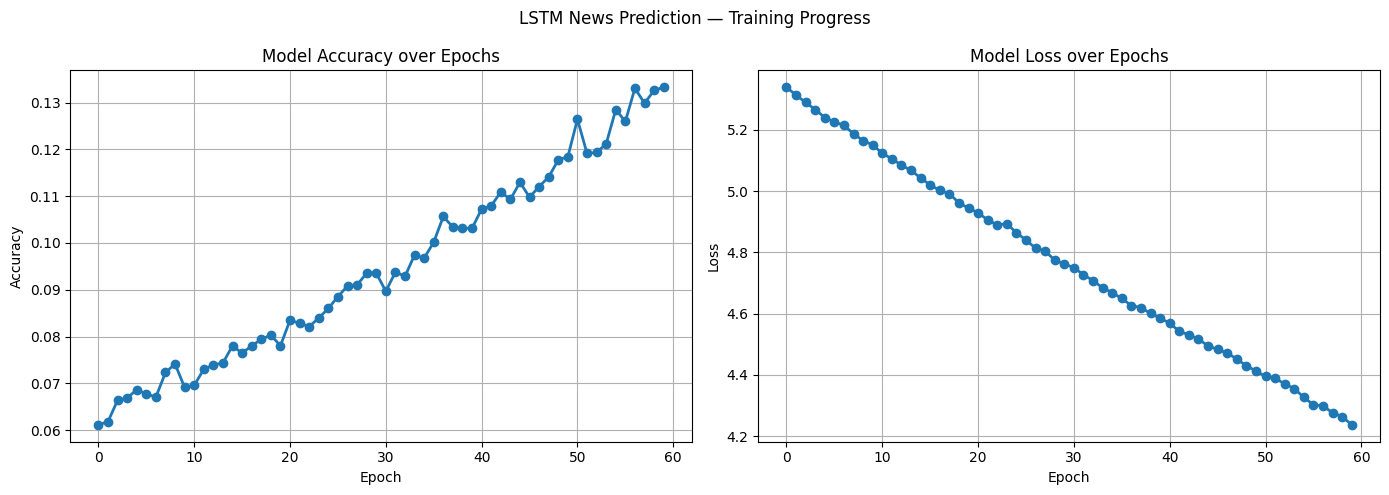

✅ Plot saved as training_progress.png


In [52]:
import matplotlib.pyplot as plt

print("\n🔹 Plotting training progress...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], linewidth=2, marker='o')
ax1.set_title('Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], linewidth=2, marker='o')
ax2.set_title('Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.grid(True)

plt.suptitle('LSTM News Prediction — Training Progress')
plt.tight_layout()

plt.savefig('training_progress.png', dpi=150)
plt.show()

print("✅ Plot saved as training_progress.png")

Test Final Model

In [53]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

print("\n🔮 Testing final model predictions...\n")

def predict_next_words(seed_text, num_words=5):
    result = seed_text

    for _ in range(num_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')

        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))

        predicted_word = tokenizer.index_word.get(predicted_index, "")
        result += " " + predicted_word

    return result

test_sentences = [
    "breaking news",
    "latest technology",
    "artificial intelligence is",
    "stock market today",
    "global economy is"
]

for sentence in test_sentences:
    prediction = predict_next_words(sentence, 5)
    print(f"🧠 Input : '{sentence}'")
    print(f"✨ Output: '{prediction}'\n")


🔮 Testing final model predictions...

🧠 Input : 'breaking news'
✨ Output: 'breaking news ai artemis up to help'

🧠 Input : 'latest technology'
✨ Output: 'latest technology one ai artemis ii ceo'

🧠 Input : 'artificial intelligence is'
✨ Output: 'artificial intelligence is the year business ai ai'

🧠 Input : 'stock market today'
✨ Output: 'stock market today the fixes to make ai'

🧠 Input : 'global economy is'
✨ Output: 'global economy is business ai ai new new'



Restart FastAPI with Updated Model

In [55]:
import nest_asyncio
import uvicorn
import threading
import pickle
import numpy as np
from pyngrok import ngrok
from fastapi import FastAPI
from pydantic import BaseModel
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("\n🔹 Restarting FastAPI with updated model...")

nest_asyncio.apply()

# Load model
loaded_model = load_model('lstm_text_model.h5')
with open('tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)

SEQ_LENGTH = 10
VOCAB_SIZE = len(loaded_tokenizer.word_index) + 1

app = FastAPI(
    title="LSTM News Prediction API",
    description="Predict next words from news headlines",
    version="2.0.0"
)

class PredictRequest(BaseModel):
    seed_text: str
    num_words: int = 5

class PredictResponse(BaseModel):
    input_text: str
    predicted_text: str
    next_words: list

@app.get("/")
def home():
    return {
        "message": "News LSTM API running!",
        "version": "2.0.0",
        "endpoints": {
            "predict": "/predict",
            "docs": "/docs",
            "health": "/health"
        }
    }

@app.get("/health")
def health():
    return {
        "status": "healthy",
        "model": "LSTM",
        "vocab_size": VOCAB_SIZE
    }

@app.post("/predict")
def predict(request: PredictRequest):
    result = request.seed_text
    next_words = []

    for _ in range(request.num_words):
        token_list = loaded_tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=SEQ_LENGTH, padding='pre')

        predicted_probs = loaded_model.predict(token_list, verbose=0)
        predicted_index = int(np.argmax(predicted_probs))

        predicted_word = loaded_tokenizer.index_word.get(predicted_index, "")

        next_words.append(predicted_word)
        result += " " + predicted_word

    return PredictResponse(
        input_text=request.seed_text,
        predicted_text=result,
        next_words=next_words
    )

# Start ngrok
ngrok.set_auth_token("3CxEWBuoeHDtAZsZfzq5rqUzkQc_2KWzW3574upArmoXD7q9G")
public_url = ngrok.connect(8000)

print(f"✅ Public URL: {public_url}")
print(f"📖 Swagger Docs: {public_url}/docs")

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server, daemon=True)
thread.start()

import time
while True:
    time.sleep(1)


🔹 Restarting FastAPI with updated model...
✅ Public URL: NgrokTunnel: "https://celibate-onyx-unshackle.ngrok-free.dev" -> "http://localhost:8000"
📖 Swagger Docs: NgrokTunnel: "https://celibate-onyx-unshackle.ngrok-free.dev" -> "http://localhost:8000"/docs


INFO:     Started server process [13057]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


INFO:     154.84.245.58:0 - "GET / HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     154.84.245.58:0 - "POST /predict HTTP/1.1" 200 OK


KeyboardInterrupt: 

Download Files

In [56]:
from google.colab import files

print("\n🔹 Downloading project files...")

files.download('lstm_text_model.h5')
files.download('tokenizer.pkl')
files.download('training_progress.png')

print("✅ Files downloading!")


🔹 Downloading project files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloading!


Save to Google Drive

In [57]:
from google.colab import drive
import shutil

print("\n🔹 Saving to Google Drive...")

drive.mount('/content/drive')

shutil.copy('lstm_text_model.h5', '/content/drive/MyDrive/lstm_text_model.h5')
shutil.copy('tokenizer.pkl', '/content/drive/MyDrive/tokenizer.pkl')

print("✅ Model saved to Drive!")
print("✅ Tokenizer saved to Drive!")


🔹 Saving to Google Drive...
Mounted at /content/drive
✅ Model saved to Drive!
✅ Tokenizer saved to Drive!
